# Lecture Example: Human-Robot Distance

In [1]:
import jax
import jax.numpy as jnp
from stljax.formula import Predicate, Always, Eventually, Until


T = 10
distance = jnp.array([3.0, 2.8, 2.5, 2.2, 1.8, 1.5, 1.2, 0.9, 0.7, 0.6])

# Define the STL specification
d_pred = Predicate("d", lambda x: x)
safety_spec = Always(d_pred >= 1.0)  # G(d >= 1.0)

# Evaluate robustness
robustness = safety_spec(distance)
overall_rob = robustness[0]

print(f"Overall robustness: {overall_rob:.4f}")
print(f"Specification {'SATISFIED' if overall_rob > 0 else 'VIOLATED'}")
# Overall robustness: 0.1000
# Specification SATISFIED

Overall robustness: -0.4000
Specification VIOLATED


In [14]:
import optax
import chex

# Start from the original (violated) signal
signal = jnp.array([3.0, 2.8, 2.5, 2.2, 1.8, 1.5, 1.2, 0.9, 0.7, 0.6])


def loss_fn(sig: chex.Array) -> float:
    """Loss function to maximize robustness.
    We add a regularization term to keep the optimized signal close to the original."""
    rob = safety_spec(sig)[0]
    reg = 0.1 * jnp.sum((sig - distance) ** 2)  # stay close to original
    loss = -rob + reg
    return loss


# Compute gradients and optimize the signal
grad_fn = jax.grad(loss_fn)
optimizer = optax.adam(learning_rate=0.05)
opt_state = optimizer.init(signal)

verbose = True
for i in range(200):
    grads = grad_fn(signal)
    if verbose and i % 2 == 0:
        current_rob = safety_spec(signal)[0]
        print(f"Iteration {i}, Robustness: {current_rob:.4f}, Loss: {loss_fn(signal):.4f}")
        print(f"Gradients: {grads}\n")
    updates, opt_state = optimizer.update(grads, opt_state)
    signal = optax.apply_updates(signal, updates)

    rob = safety_spec(signal)[0]
    if rob > 0:
        print(f"Specification satisfied at iteration {i} with robustness {rob:.4f}")
        break

# Evaluate the optimized signal
rob_opt = safety_spec(signal)[0]
print(f"Optimized robustness: {rob_opt:.4f}")
print(f"Specification {'SATISFIED' if rob_opt > 0 else 'VIOLATED'}")

Iteration 0, Robustness: -0.4000, Loss: 0.4000
Gradients: [ 0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]

Iteration 2, Robustness: -0.3000, Loss: 0.3010
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.98000294]

Iteration 4, Robustness: -0.2709, Loss: 0.2747
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -0.9941888   0.03807202]

Iteration 6, Robustness: -0.1935, Loss: 0.2009
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -0.97869015  0.05042386]

Iteration 8, Robustness: -0.1046, Loss: 0.1172
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.          0.         -0.9609119   0.05925032]

Iteration 10, Robustness: -0.0758, Loss: 0.0946
Gradients: [ 0.          0.          0.          0.          0.          0.
  0.         -0.99515575  0.05665908  0.06554996]

Iteration 12, Robustness: -0

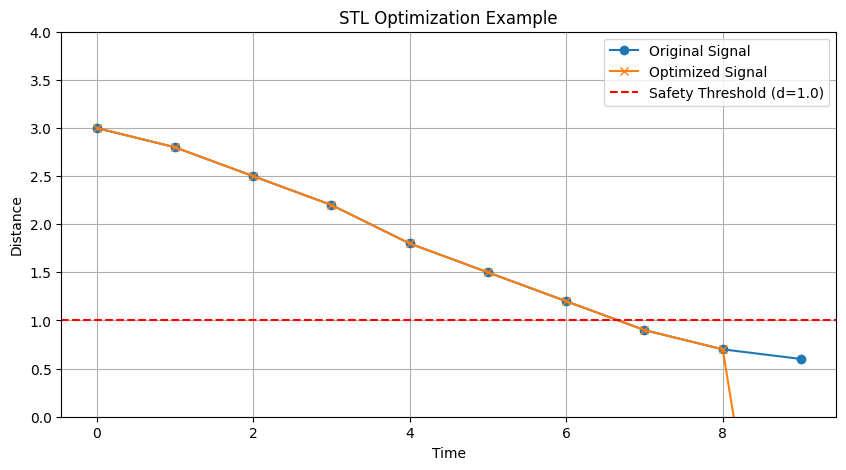

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot original and optimized signals
plt.plot(distance, label="Original Signal", marker="o")
plt.plot(signal, label="Optimized Signal", marker="x")

# Plot the threshold line for safety
plt.axhline(1.0, color="red", linestyle="--", label="Safety Threshold (d=1.0)")


plt.ylim(0, 4)

plt.xlabel("Time")
plt.ylabel("Distance")
plt.title("STL Optimization Example")
plt.legend()
plt.grid(True)
plt.show()